<a href="https://colab.research.google.com/github/anchietajunior/pdi2026/blob/main/pdi_01_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imagem original ----------------------


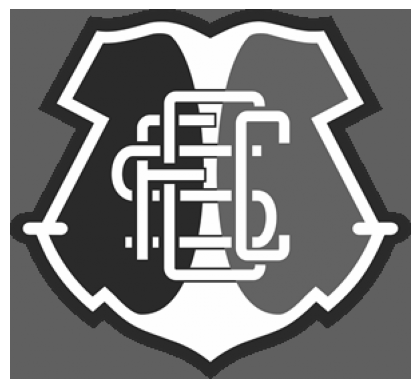

Shape (277, 300)
Redimensionada (com vizinhos) ----------------------


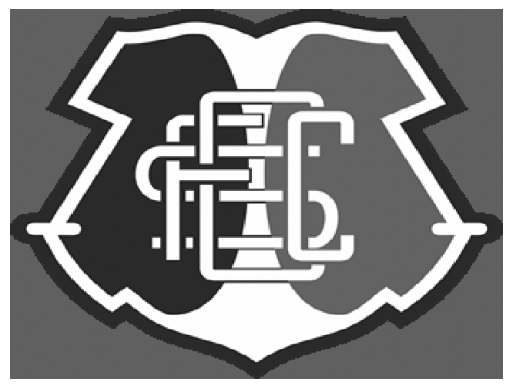

Shape (480, 640)
Redimensionada (bilinear) ----------------------


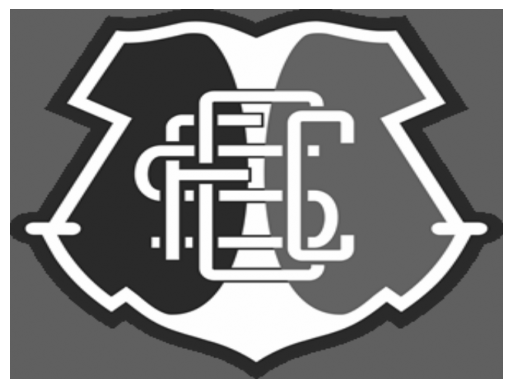

Shape (480, 640)
----------------------
HIstogramas


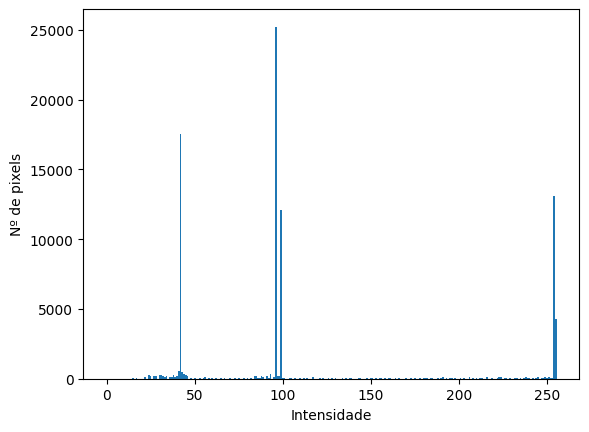

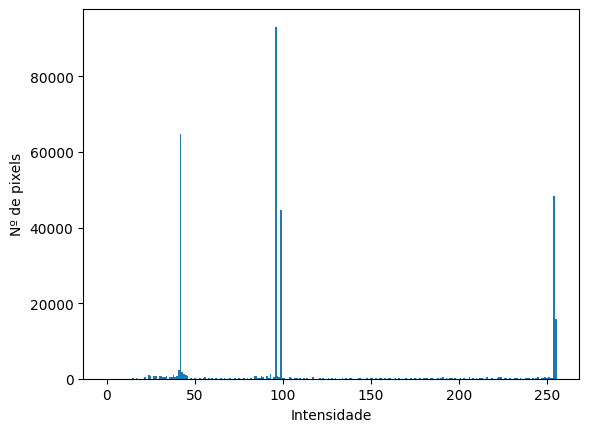

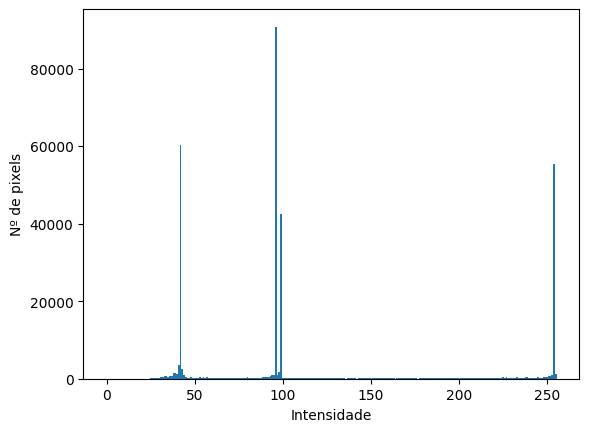

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# from google.colab import files
# files.upload()

def converter_imagem_para_tons_de_cinza(img_rgb):
    if img_rgb.ndim == 2:
      return img_rgb

    r = img_rgb[:, :, 0].astype(np.float64)
    g = img_rgb[:, :, 1].astype(np.float64)
    b = img_rgb[:, :, 2].astype(np.float64)
    cinza = 0.299 * r + 0.587 * g + 0.114 * b
    return np.round(cinza).astype(np.uint8)

def gerar_histograma(img):
    return np.bincount(img.flatten(), minlength=256)

def redimensionar_imagem(img, alt_nova, larg_nova):
    alt, larg = img.shape
    ys = np.arange(alt_nova) * alt // alt_nova
    xs = np.arange(larg_nova) * larg // larg_nova
    return img[ys][:, xs]

def redimensionar_imagem_bilinear(img, alt_nova, larg_nova):
    alt, larg = img.shape
    img = img.astype(np.float64)

    y_orig = np.arange(alt_nova) * (alt - 1) / (alt_nova - 1)
    x_orig = np.arange(larg_nova) * (larg - 1) / (larg_nova - 1)

    # cantos superiores esquerdos
    y0 = y_orig.astype(int)
    x0 = x_orig.astype(int)
    # vizinhos com proteção de borda
    y1 = np.minimum(y0 + 1, alt - 1)
    x1 = np.minimum(x0 + 1, larg - 1)

    dy = (y_orig - y0)[:, None]
    dx = x_orig - x0

    topo = img[y0[:, None], x0] * (1 - dx) + img[y0[:, None], x1] * dx
    base = img[y1[:, None], x0] * (1 - dx) + img[y1[:, None], x1] * dx
    saida = topo * (1 - dy) + base * dy
    return saida.astype(np.uint8)

img_01 = converter_imagem_para_tons_de_cinza(np.array(Image.open("/content/img_2.png").convert("RGBA")))

print("Imagem original ----------------------")

plt.imshow(img_01, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

print("Shape", img_01.shape)
print("Redimensionada (com vizinhos) ----------------------")

img_01_redimensionada = redimensionar_imagem(img_01, 480, 640)
plt.imshow(img_01_redimensionada, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

print("Shape", img_01_redimensionada.shape)
print("Redimensionada (bilinear) ----------------------")

img_01_redimensionada_biliniear = redimensionar_imagem_bilinear(img_01, 480, 640)
plt.imshow(img_01_redimensionada_biliniear, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

print("Shape", img_01_redimensionada_biliniear.shape)
print("----------------------")
print("HIstogramas")

plt.bar(range(256), gerar_histograma(img_01), width=1)
plt.xlabel('Intensidade'); plt.ylabel('Nº de pixels')
plt.show()

plt.bar(range(256), gerar_histograma(img_01_redimensionada), width=1)
plt.xlabel('Intensidade'); plt.ylabel('Nº de pixels')
plt.show()

plt.bar(range(256), gerar_histograma(img_01_redimensionada_biliniear), width=1)
plt.xlabel('Intensidade'); plt.ylabel('Nº de pixels')
plt.show()

